In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, RationalQuadratic, WhiteKernel, Matern
from sklearn.gaussian_process.kernels import Kernel

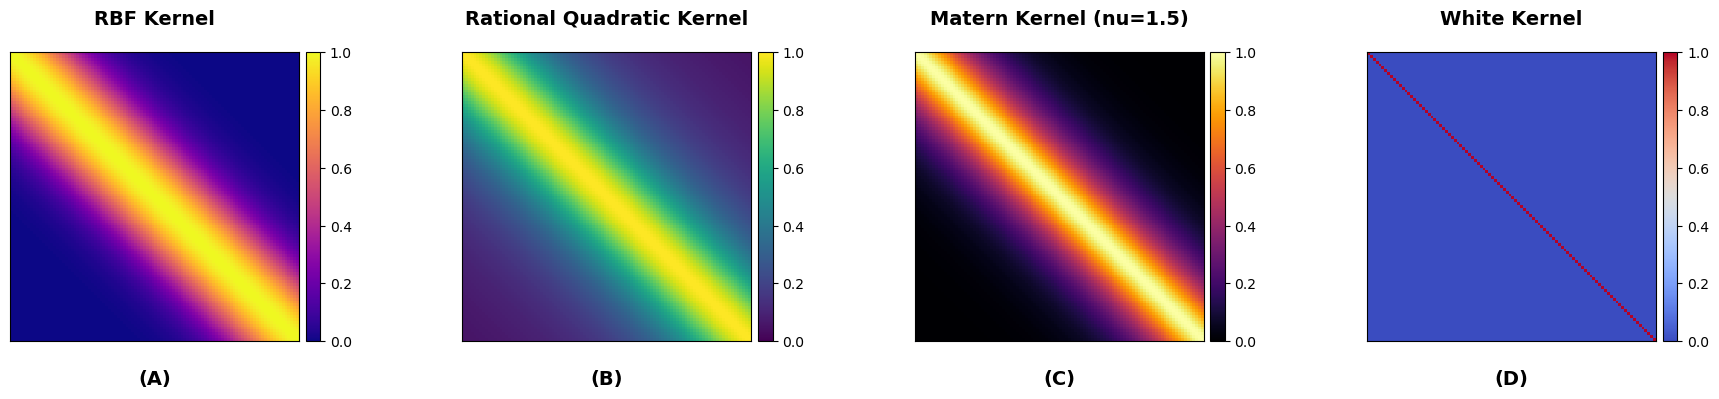

In [2]:
def plot_covariance_matrix(kernel: Kernel, X: np.ndarray, ax: plt.Axes, title: str, cmap: str, vmin: float, vmax: float):
    """Compute and plot the covariance matrix for a given kernel."""
    K = kernel(X)
    cax = ax.matshow(K, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(cax, ax=ax, shrink=0.75, pad=0.02)

# Define the range of X
X = np.linspace(-3, 3, 100).reshape(-1, 1)

# Create subplots for each kernel
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
plt.subplots_adjust(wspace=0.3)

# Define kernels with unique color maps
kernels = [
    (RBF(length_scale=1.0), 'RBF Kernel', 'plasma'),
    (RationalQuadratic(alpha=1.0, length_scale=1.0), 'Rational Quadratic Kernel', 'viridis'),
    (Matern(length_scale=1.0, nu=1.5), 'Matern Kernel (nu=1.5)', 'inferno'),
    (WhiteKernel(noise_level=1.0), 'White Kernel', 'coolwarm')
]

# Calculate covariance matrices to determine the common color scale
all_matrices = []
for kernel, _, _ in kernels:
    K = kernel(X)
    all_matrices.append(K)

# Find global min and max values for consistent color scaling
all_matrices = np.concatenate([K.flatten() for K in all_matrices])
vmin, vmax = all_matrices.min(), all_matrices.max()

# Plot each kernel's covariance matrix with distinct color maps
labels = ['(A)', '(B)', '(C)', '(D)']
for i, (kernel, title, cmap) in enumerate(kernels):
    plot_covariance_matrix(kernel, X, axes[i], title, cmap, vmin, vmax)
    axes[i].text(0.5, -0.1, labels[i], transform=axes[i].transAxes, fontsize=14, fontweight='bold', va='top', ha='center')



plt.show()


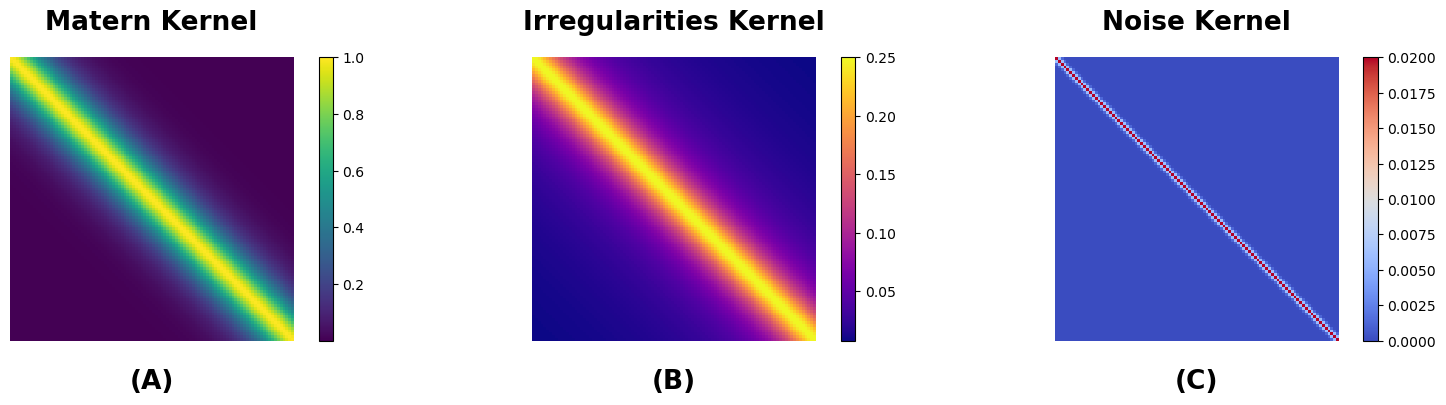

In [7]:
# Define a grid of points
x = np.linspace(0, 10, 100).reshape(-1, 1)

# Define the kernels
matern_kernel = 1.0**2 * Matern(length_scale=1.0, nu=1.5)
irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=0.7, alpha=0.7)
noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1**2)

# Compute covariance matrices
def compute_covariance_matrix(kernel, X):
    return kernel(X)

K_matern = compute_covariance_matrix(matern_kernel, x)
K_irregularities = compute_covariance_matrix(irregularities_kernel, x)
K_noise = compute_covariance_matrix(noise_kernel, x)

# Define NCD kernel (combination of the above kernels)
ncd_kernel = matern_kernel + irregularities_kernel + noise_kernel
K_ncd = compute_covariance_matrix(ncd_kernel, x)

# Plotting the individual kernels
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)

# Labels for subplots
labels = ['(A)', '(B)', '(C)']

# Plot each kernel with labels and bold titles
im_matern = axes[0].imshow(K_matern, cmap='viridis', interpolation='nearest')
axes[0].set_title('Matern Kernel', fontweight='bold', fontsize=19, pad=20)
axes[0].axis('off')
axes[0].text(0.5, -0.1, labels[0], transform=axes[0].transAxes, fontsize=19, fontweight='bold', va='top', ha='center')

im_irregularities = axes[1].imshow(K_irregularities, cmap='plasma', interpolation='nearest')
axes[1].set_title('Irregularities Kernel', fontweight='bold', fontsize=19, pad=20)
axes[1].axis('off')
axes[1].text(0.5, -0.1, labels[1], transform=axes[1].transAxes, fontsize=19, fontweight='bold', va='top', ha='center')

im_noise = axes[2].imshow(K_noise, cmap='coolwarm', interpolation='nearest')
axes[2].set_title('Noise Kernel', fontweight='bold', fontsize=19, pad=20)
axes[2].axis('off')
axes[2].text(0.5, -0.1, labels[2], transform=axes[2].transAxes, fontsize=19, fontweight='bold', va='top', ha='center')

# Add colorbars
fig.colorbar(im_matern, ax=axes[0], orientation='vertical')
fig.colorbar(im_irregularities, ax=axes[1], orientation='vertical')
fig.colorbar(im_noise, ax=axes[2], orientation='vertical')

plt.tight_layout()



plt.show()






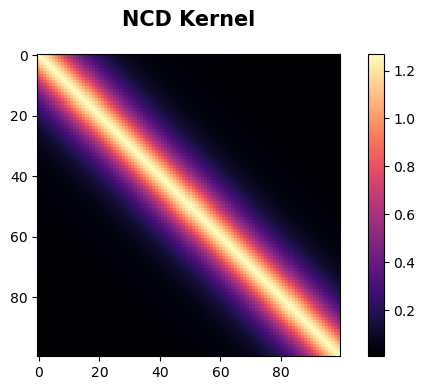

In [9]:
# Plotting the NCD kernel separately
fig, ax = plt.subplots(figsize=(6, 4))
im_ncd = ax.imshow(K_ncd, cmap='magma', interpolation='nearest')
ax.set_title('NCD Kernel', fontweight='bold', fontsize=15, pad=20)

# Add colorbar
fig.colorbar(im_ncd, ax=ax, orientation='vertical')

plt.tight_layout()


plt.show()